In [1]:
import pandas as pd 

In [2]:
survey_results = pd.read_csv('survey_results_public.csv')

In [3]:
survey_results.head()

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8


In [4]:
print(survey_results['DevType'].head(20))

0     Developer, desktop or enterprise applications;...
1               Developer, full-stack;Developer, mobile
2                                                   NaN
3                                                   NaN
4                                                   NaN
5       Designer;Developer, front-end;Developer, mobile
6     Developer, back-end;Developer, front-end;Devel...
7     Developer, back-end;Developer, desktop or ente...
8                                 Developer, full-stack
9     Database administrator;Developer, full-stack;D...
10    Developer, back-end;Developer, desktop or ente...
11                        Designer;Developer, front-end
12                         Designer;Developer, back-end
13    Developer, desktop or enterprise applications;...
14                                                  NaN
15    Database administrator;Developer, back-end;Dev...
16                                Developer, full-stack
17                                  Developer, b

*Schema_raw contain only one column so we have conteverted it into a series (by applying that column name with '.' in the end (like-> .QuestionText)*

In [5]:
schema_raw = pd.read_csv('survey_results_schema.csv', index_col = 'Column').QuestionText

In [6]:
schema_raw.head()

Column
Respondent    Randomized respondent ID number (not in order ...
MainBranch    Which of the following options best describes ...
Hobbyist                                Do you code as a hobby?
Age           What is your age (in years)? If you prefer not...
Age1stCode    At what age did you write your first line of c...
Name: QuestionText, dtype: object

In [7]:
schema_raw['Respondent']
schema_raw['DevType']

'Which of the following describe you? Please select all that apply.'

# Now the most important part is , out of this huge dataset containing 60 columns as questions , what we need to take care of , a real analyst don't sit with the whole columns instead he prioretise columns based on what he want's to know from the data(insights we can say) then the rest is just noise.  

# so in this we will have three lens - 
# Demographics , Programming Experience and Employement

In [8]:
survey_results.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'Age', 'Age1stCode', 'CompFreq',
       'CompTotal', 'ConvertedComp', 'Country', 'CurrencyDesc',
       'CurrencySymbol', 'DatabaseDesireNextYear', 'DatabaseWorkedWith',
       'DevType', 'EdLevel', 'Employment', 'Ethnicity', 'Gender', 'JobFactors',
       'JobSat', 'JobSeek', 'LanguageDesireNextYear', 'LanguageWorkedWith',
       'MiscTechDesireNextYear', 'MiscTechWorkedWith',
       'NEWCollabToolsDesireNextYear', 'NEWCollabToolsWorkedWith', 'NEWDevOps',
       'NEWDevOpsImpt', 'NEWEdImpt', 'NEWJobHunt', 'NEWJobHuntResearch',
       'NEWLearn', 'NEWOffTopic', 'NEWOnboardGood', 'NEWOtherComms',
       'NEWOvertime', 'NEWPurchaseResearch', 'NEWPurpleLink', 'NEWSOSites',
       'NEWStuck', 'OpSys', 'OrgSize', 'PlatformDesireNextYear',
       'PlatformWorkedWith', 'PurchaseWhat', 'Sexuality', 'SOAccount',
       'SOComm', 'SOPartFreq', 'SOVisitFreq', 'SurveyEase', 'SurveyLength',
       'Trans', 'UndergradMajor', 'WebframeDesireNextYear',
  

In [9]:
selected_col = [
    # Demographics 
    'Age',
    'Country',
    'EdLevel',
    'Gender',
    'UndergradMajor',

    # Programming Experience 
    'Age1stCode',
    'LanguageDesireNextYear',
    'LanguageWorkedWith',
    'Hobbyist',
    'YearsCode',
    'YearsCodePro',
    'NEWLearn',
    'NEWStuck',

    # Employement
    'Employment',
    'NEWEdImpt',
    'NEWOvertime',
    'WorkWeekHrs',
    'JobSat',
    'DevType',
    'JobFactors'
    
    
]

In [10]:
survey = survey_results[selected_col]
schema = schema_raw[selected_col]

In [11]:
survey.head(19)

,Age,Country,EdLevel,Gender,UndergradMajor,Age1stCode,LanguageDesireNextYear,LanguageWorkedWith,Hobbyist,YearsCode,YearsCodePro,NEWLearn,NEWStuck,Employment,NEWEdImpt,NEWOvertime,WorkWeekHrs,JobSat,DevType,JobFactors
0,NaN,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",13,C#;HTML/CSS;JavaScript,C#;HTML/CSS;JavaScript,Yes,36,27,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...",Fairly important,Often: 1-2 days per week or more,50.0,Slightly satisfied,"Developer, desktop or enterprise applications;...","Languages, frameworks, and other technologies ..."
1,NaN,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Computer science, computer engineering, or sof...",19,Python;Swift,JavaScript;Swift,No,7,4,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,Fairly important,NaN,NaN,Very dissatisfied,"Developer, full-stack;Developer, mobile",NaN
2,NaN,Russian Federation,NaN,NaN,NaN,15,Objective-C;Python;Swift,Objective-C;Python;Swift,Yes,4,NaN,Once a decade,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25.0,Albania,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",18,NaN,NaN,Yes,7,4,Once a year,NaN,NaN,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,40.0,Slightly dissatisfied,NaN,Flex time or a flexible schedule;Office enviro...
4,31.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",16,Java;Ruby;Scala,HTML/CSS;Ruby;SQL,Yes,15,8,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,Very important,NaN,NaN,NaN,NaN,NaN
5,NaN,Germany,"Secondary school (e.g. American high school, G...",Man,NaN,14,HTML/CSS;Java;JavaScript,HTML/CSS;Java;JavaScript,No,6,4,Once a year,Play games;Visit Stack Overflow;Watch help / t...,Employed full-time,Fairly important,Never,NaN,Slightly satisfied,"Designer;Developer, front-end;Developer, mobile",Diversity of the company or organization;Langu...
6,NaN,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Computer science, computer engineering, or sof...",18,C#;HTML/CSS;PHP,C#;HTML/CSS;PHP,Yes,6,4,Every few months,NaN,Employed full-time,Very important,Sometimes: 1-2 days per month but less than we...,NaN,Very satisfied,"Developer, back-end;Developer, front-end;Devel...",NaN
7,36.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",12,JavaScript,Python;SQL,Yes,17,13,Once a year,Play games;Call a coworker or friend;Visit Sta...,Employed full-time,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,39.0,Slightly dissatisfied,"Developer, back-end;Developer, desktop or ente...",Remote work options;Opportunities for professi...
8,30.0,Tunisia,"Professional degree (JD, MD, etc.)",Man,"Computer science, computer engineering, or sof...",20,Python;Rust,HTML/CSS;JavaScript;PHP,No,6,4,Once a year,Meditate,"Independent contractor, freelancer, or self-em...",Very important,Occasionally: 1-2 days per quarter but less th...,50.0,Very dissatisfied,"Developer, full-stack",Diversity of the company or organization;Remot...
9,22.0,United Kingdom,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,Mathematics or statistics,14,HTML/CSS;Java;JavaScript;Python;R;SQL,HTML/CSS;Java;JavaScript;Python;SQL,Yes,8,4,Every few months,Visit Stack Overflow,Employed full-time,Fairly important,Often: 1-2 days per week or more,36.0,Very satisfied,"Database administrator;Developer, full-stack;D...",Flex time or a flexible schedule;How widely us...


In [12]:
survey.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     45446 non-null  float64
 1   Country                 64072 non-null  object 
 2   EdLevel                 57431 non-null  object 
 3   Gender                  50557 non-null  object 
 4   UndergradMajor          50995 non-null  object 
 5   Age1stCode              57900 non-null  object 
 6   LanguageDesireNextYear  54113 non-null  object 
 7   LanguageWorkedWith      57378 non-null  object 
 8   Hobbyist                64416 non-null  object 
 9   YearsCode               57684 non-null  object 
 10  YearsCodePro            46349 non-null  object 
 11  NEWLearn                56156 non-null  object 
 12  NEWStuck                54983 non-null  object 
 13  Employment              63854 non-null  object 
 14  NEWEdImpt               48465 non-null

In [13]:
survey['Age1stCode'] = pd.to_numeric(survey.Age1stCode , errors = 'coerce')
survey['YearsCode'] = pd.to_numeric(survey.YearsCode , errors = 'coerce')
survey['YearsCodePro'] = pd.to_numeric(survey.YearsCodePro , errors = 'coerce')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\2325123120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey['Age1stCode'] = pd.to_numeric(survey.Age1stCode , errors = 'coerce')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\2325123120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey['YearsCode'] = pd.to_numeric(survey.YearsCode , errors = 'coerce')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\2325123120.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [14]:
survey['YearsCodePro'].unique()

array([27.,  4., nan,  8., 13.,  2.,  7., 20.,  1., 23.,  3., 12., 17.,
       18., 10., 14., 29.,  6., 28.,  9., 15., 11., 16., 25.,  5., 21.,
       19., 35., 24., 32., 22., 30., 38., 26., 40., 33., 31., 34., 36.,
       39., 37., 41., 45., 47., 42., 46., 50., 43., 44., 48., 49.])

In [15]:
survey.describe()

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
count,45446.000000,57473.000000,56784.000000,44133.000000,41151.000000
mean,30.834111,15.476572,12.782051,8.869667,40.782174
std,9.585392,5.114081,9.490657,7.759961,17.816383
min,1.000000,5.000000,1.000000,1.000000,1.000000
25%,24.000000,12.000000,6.000000,3.000000,40.000000
50%,29.000000,15.000000,10.000000,6.000000,40.000000
75%,35.000000,18.000000,17.000000,12.000000,44.000000
max,279.000000,85.000000,50.000000,50.000000,475.000000


In [16]:
survey.drop(survey[survey['Age']>100].index,inplace = True)
survey.drop(survey[survey['Age']<10].index,inplace = True)
survey.drop(survey[survey['WorkWeekHrs']>140].index,inplace = True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\4233142630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey.drop(survey[survey['Age']>100].index,inplace = True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\4233142630.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey.drop(survey[survey['Age']<10].index,inplace = True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\4233142630.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a

In [17]:
survey.shape

(64306, 20)

In [18]:
survey.head(10)

,Age,Country,EdLevel,Gender,UndergradMajor,Age1stCode,LanguageDesireNextYear,LanguageWorkedWith,Hobbyist,YearsCode,YearsCodePro,NEWLearn,NEWStuck,Employment,NEWEdImpt,NEWOvertime,WorkWeekHrs,JobSat,DevType,JobFactors
0,NaN,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",13.0,C#;HTML/CSS;JavaScript,C#;HTML/CSS;JavaScript,Yes,36.0,27.0,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...",Fairly important,Often: 1-2 days per week or more,50.0,Slightly satisfied,"Developer, desktop or enterprise applications;...","Languages, frameworks, and other technologies ..."
1,NaN,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Computer science, computer engineering, or sof...",19.0,Python;Swift,JavaScript;Swift,No,7.0,4.0,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,Fairly important,NaN,NaN,Very dissatisfied,"Developer, full-stack;Developer, mobile",NaN
2,NaN,Russian Federation,NaN,NaN,NaN,15.0,Objective-C;Python;Swift,Objective-C;Python;Swift,Yes,4.0,NaN,Once a decade,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25.0,Albania,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",18.0,NaN,NaN,Yes,7.0,4.0,Once a year,NaN,NaN,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,40.0,Slightly dissatisfied,NaN,Flex time or a flexible schedule;Office enviro...
4,31.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",16.0,Java;Ruby;Scala,HTML/CSS;Ruby;SQL,Yes,15.0,8.0,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,Very important,NaN,NaN,NaN,NaN,NaN
5,NaN,Germany,"Secondary school (e.g. American high school, G...",Man,NaN,14.0,HTML/CSS;Java;JavaScript,HTML/CSS;Java;JavaScript,No,6.0,4.0,Once a year,Play games;Visit Stack Overflow;Watch help / t...,Employed full-time,Fairly important,Never,NaN,Slightly satisfied,"Designer;Developer, front-end;Developer, mobile",Diversity of the company or organization;Langu...
6,NaN,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Computer science, computer engineering, or sof...",18.0,C#;HTML/CSS;PHP,C#;HTML/CSS;PHP,Yes,6.0,4.0,Every few months,NaN,Employed full-time,Very important,Sometimes: 1-2 days per month but less than we...,NaN,Very satisfied,"Developer, back-end;Developer, front-end;Devel...",NaN
7,36.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",12.0,JavaScript,Python;SQL,Yes,17.0,13.0,Once a year,Play games;Call a coworker or friend;Visit Sta...,Employed full-time,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,39.0,Slightly dissatisfied,"Developer, back-end;Developer, desktop or ente...",Remote work options;Opportunities for professi...
8,30.0,Tunisia,"Professional degree (JD, MD, etc.)",Man,"Computer science, computer engineering, or sof...",20.0,Python;Rust,HTML/CSS;JavaScript;PHP,No,6.0,4.0,Once a year,Meditate,"Independent contractor, freelancer, or self-em...",Very important,Occasionally: 1-2 days per quarter but less th...,50.0,Very dissatisfied,"Developer, full-stack",Diversity of the company or organization;Remot...
9,22.0,United Kingdom,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,Mathematics or statistics,14.0,HTML/CSS;Java;JavaScript;Python;R;SQL,HTML/CSS;Java;JavaScript;Python;SQL,Yes,8.0,4.0,Every few months,Visit Stack Overflow,Employed full-time,Fairly important,Often: 1-2 days per week or more,36.0,Very satisfied,"Database administrator;Developer, full-stack;D...",Flex time or a flexible schedule;How widely us...


In [19]:
survey['Gender'].value_counts()

Gender
Man                                                            45895
Woman                                                           3835
Non-binary, genderqueer, or gender non-conforming                385
Man;Non-binary, genderqueer, or gender non-conforming            121
Woman;Non-binary, genderqueer, or gender non-conforming           92
Woman;Man                                                         73
Woman;Man;Non-binary, genderqueer, or gender non-conforming       25
Name: count, dtype: int64

In [20]:
import numpy as np

In [21]:
# survey.where(~(survey.Gender.str.contains(';',na = False)),np.nan, inplace = True)

In [22]:
len(selected_col)

20

In [23]:
survey.shape

(64306, 20)

In [24]:
len(survey[survey.Gender.str.contains(';',na = False)])

311

In [25]:
(311/survey.shape[0]) * 100

0.483625167169471

In [26]:
survey.drop(survey[survey.Gender.str.contains(';',na = False)].index , inplace = True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\1534646638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey.drop(survey[survey.Gender.str.contains(';',na = False)].index , inplace = True)


In [27]:
survey.shape

(63995, 20)

In [28]:
survey['Gender'].value_counts()

Gender
Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: count, dtype: int64

In [29]:
survey.sample(10)

,Age,Country,EdLevel,Gender,UndergradMajor,Age1stCode,LanguageDesireNextYear,LanguageWorkedWith,Hobbyist,YearsCode,YearsCodePro,NEWLearn,NEWStuck,Employment,NEWEdImpt,NEWOvertime,WorkWeekHrs,JobSat,DevType,JobFactors
40021,NaN,Egypt,Primary/elementary school,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15028,25.0,France,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Woman,Web development or web design,15.0,HTML/CSS;Java;JavaScript;Ruby;SQL;TypeScript,Bash/Shell/PowerShell;HTML/CSS;Java;JavaScript...,No,10.0,4.0,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,Very important,Rarely: 1-2 days per year or less,39.0,Slightly dissatisfied,"Developer, full-stack;Developer, mobile","Flex time or a flexible schedule;Languages, fr..."
26656,30.0,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",18.0,Dart;Kotlin,Java,Yes,11.0,8.0,Once every few years,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,Somewhat important,Occasionally: 1-2 days per quarter but less th...,40.0,Very satisfied,"Developer, mobile","Flex time or a flexible schedule;Languages, fr..."
53612,NaN,Bhutan,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Computer science, computer engineering, or sof...",18.0,HTML/CSS;JavaScript;TypeScript,C;HTML/CSS;Java;Kotlin;SQL,Yes,5.0,1.0,Once a year,Visit Stack Overflow,Employed full-time,Critically important,Often: 1-2 days per week or more,43.0,Neither satisfied nor dissatisfied,"Developer, front-end;Developer, mobile","Languages, frameworks, and other technologies ..."
703,42.0,Canada,Some college/university study without earning ...,Man,"Computer science, computer engineering, or sof...",16.0,Bash/Shell/PowerShell;C#;Python;SQL,Assembly;C;C#;C++;HTML/CSS;Java;JavaScript;Obj...,Yes,20.0,16.0,Every few months,Visit Stack Overflow;Watch help / tutorial vid...,Employed full-time,Not at all important/not necessary,Never,37.0,Neither satisfied nor dissatisfied,"Data or business analyst;Developer, full-stack",Flex time or a flexible schedule;Remote work o...
58123,20.0,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",14.0,C++;Go;Haskell;JavaScript;Python,C++;HTML/CSS;JavaScript;Python,Yes,5.0,NaN,Every few months,Visit Stack Overflow;Watch help / tutorial vid...,Student,NaN,NaN,NaN,NaN,NaN,Industry that I’d be working in;Financial perf...
15508,NaN,United States,NaN,Man,NaN,11.0,NaN,Bash/Shell/PowerShell;HTML/CSS;JavaScript,Yes,3.0,NaN,Every few months,Visit Stack Overflow;Panic;Do other work and c...,Student,NaN,NaN,NaN,NaN,NaN,NaN
60351,27.0,Canada,Some college/university study without earning ...,Man,NaN,16.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Pyth...,HTML/CSS;JavaScript;PHP;SQL,Yes,NaN,3.0,Once every few years,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,Not at all important/not necessary,Sometimes: 1-2 days per month but less than we...,50.0,Neither satisfied nor dissatisfied,"Developer, full-stack","Languages, frameworks, and other technologies ..."
22937,27.0,India,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Computer science, computer engineering, or sof...",21.0,Objective-C;Swift,Objective-C;Swift,Yes,10.0,7.0,Once a year,Call a coworker or friend;Visit Stack Overflow,Employed full-time,Fairly important,Sometimes: 1-2 days per month but less than we...,45.0,Very satisfied,"Developer, mobile",Flex time or a flexible schedule;Financial per...
34198,27.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"A natural science (such as biology, chemistry,...",13.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;S...,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;S...,Yes,4.0,3.0,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,Very important,Sometimes: 1-2 days per month but less than we...,45.0,Very satisfied,"Developer, back-end;Developer, desktop or 

# Exploratory Analysys and Visualisation 

EDA is the process of investigating your dataset to understand its main characteristics, often using summary statistics and visualizations.
Think of it as “getting to know your data before you do anything serious with it.”

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt 

In [31]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['figure.facecolor'] = '#00000000'

# Country

In [32]:
top_countries = survey.Country.value_counts().head(10)
top_countries

Country
United States     12371
India              8364
United Kingdom     3881
Germany            3864
Canada             2175
France             1884
Brazil             1804
Netherlands        1332
Poland             1259
Australia          1199
Name: count, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25860\1744105974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_countries.index , y = top_countries , palette = "viridis");


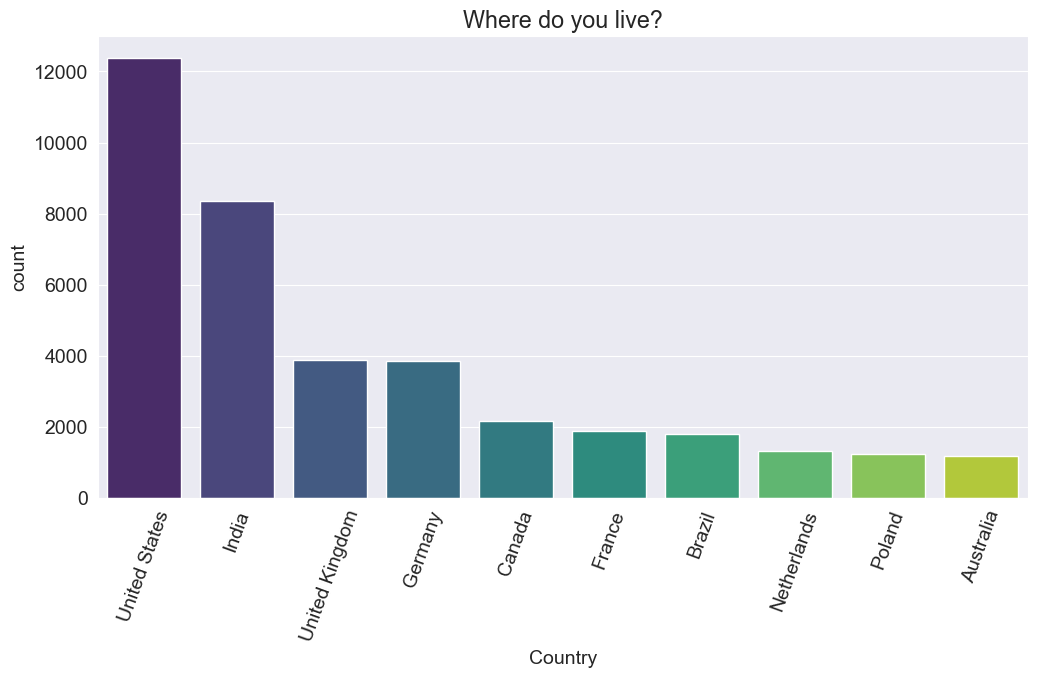

In [33]:
plt.figure(figsize =(12,6))
plt.title(schema.Country)
plt.xticks(rotation = 70)
sns.barplot(x = top_countries.index , y = top_countries , palette = "viridis");

(array([2.0900e+02, 2.4190e+03, 9.1350e+03, 1.1938e+04, 8.7390e+03,
        5.5820e+03, 3.0310e+03, 1.7560e+03, 1.0380e+03, 6.2200e+02,
        3.3300e+02, 1.4300e+02, 7.1000e+01, 2.4000e+01, 9.0000e+00,
        6.0000e+00, 3.0000e+00]),
 array([10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70.,
        75., 80., 85., 90., 95.]),
 <BarContainer object of 17 artists>)

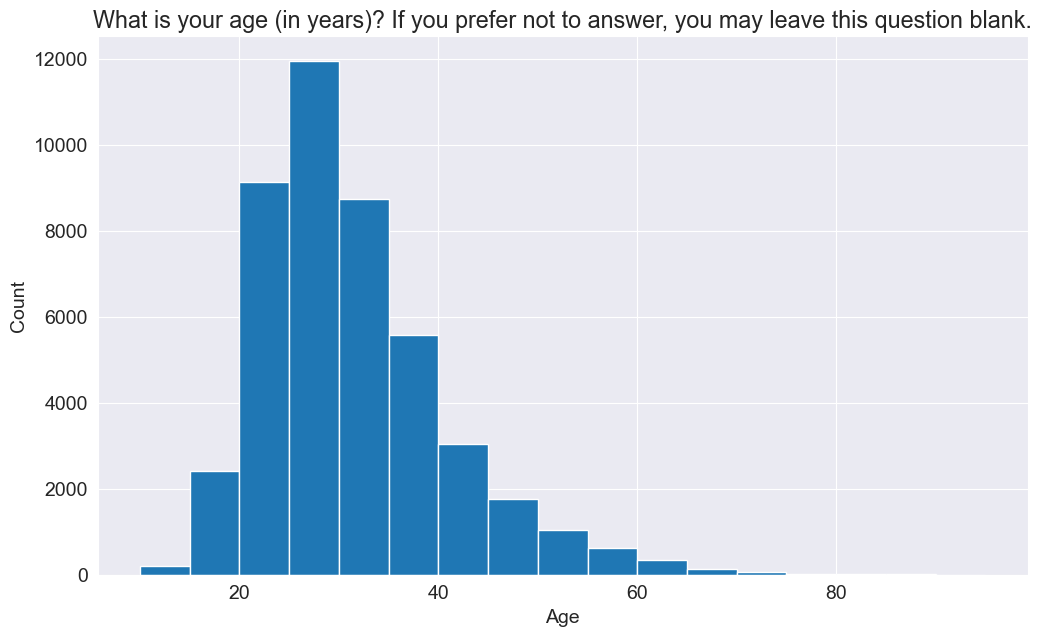

In [34]:
plt.figure(figsize = (12,7))
plt.title(schema.Age)
plt.xlabel('Age')
plt.ylabel('Count')
plt.hist(survey.Age , bins = np.arange(10,100,5))

# Gender

In [35]:
gend = survey.Gender.value_counts()
gend

Gender
Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x29a1ab9be00>,
 [Text(0.6284601926377748, -0.9027944319000263, 'Man'),
  Text(-0.6064905302525921, 0.917697791603494, 'Woman'),
  Text(-0.8253404719798475, 0.7271953694242578, 'Non-binary, genderqueer, or gender non-conforming')],
 [Text(0.3427964687115134, -0.49243332649092336, '91.6%'),
  Text(-0.33081301650141387, 0.500562431783724, '7.7%'),
  Text(-0.4501857119890077, 0.39665201968595876, '0.8%')])

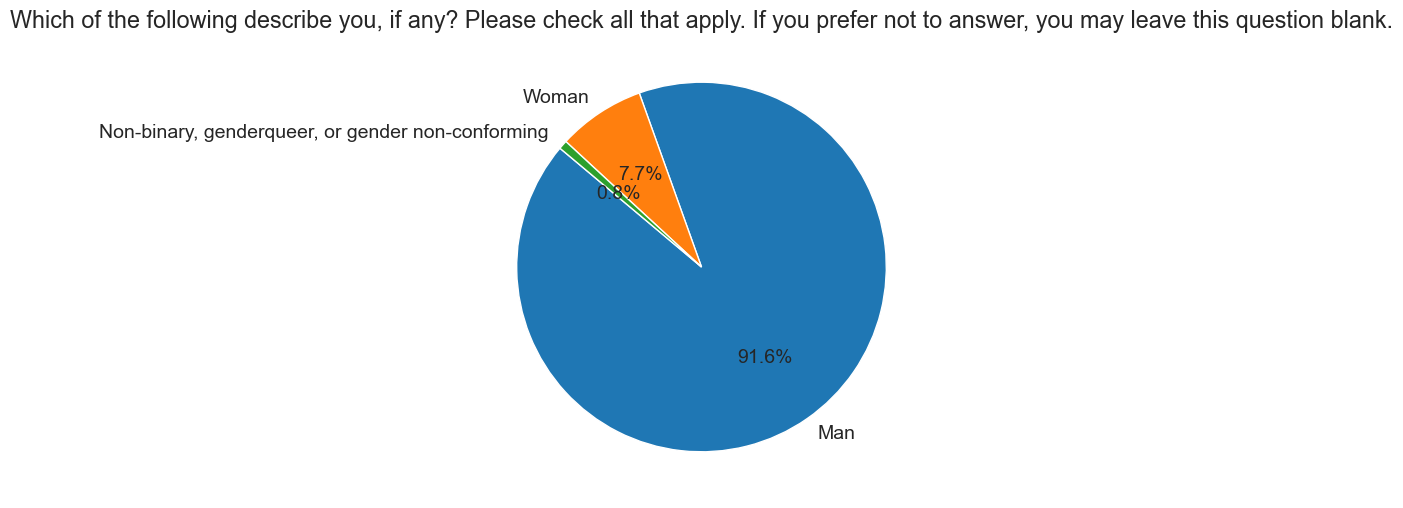

In [36]:
plt.figure(figsize = (12,6))
plt.title(schema.Gender)
plt.pie(gend , labels = gend.index, autopct = '%1.1f%%' , startangle = 140 )

# Education Level

In [37]:
schema.EdLevel

'Which of the following best describes the highest level of formal education that you’ve completed?'

In [38]:
survey.EdLevel.value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          26356
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       13024
Some college/university study without earning a degree                                 7163
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     4724
Associate degree (A.A., A.S., etc.)                                                    1831
Other doctoral degree (Ph.D., Ed.D., etc.)                                             1681
Primary/elementary school                                                               929
Professional degree (JD, MD, etc.)                                                      793
I never completed any formal education                                                  480
Name: count, dtype: int64

<Axes: title={'center': 'Which of the following best describes the highest level of formal education that you’ve completed?'}, xlabel='count', ylabel='EdLevel'>

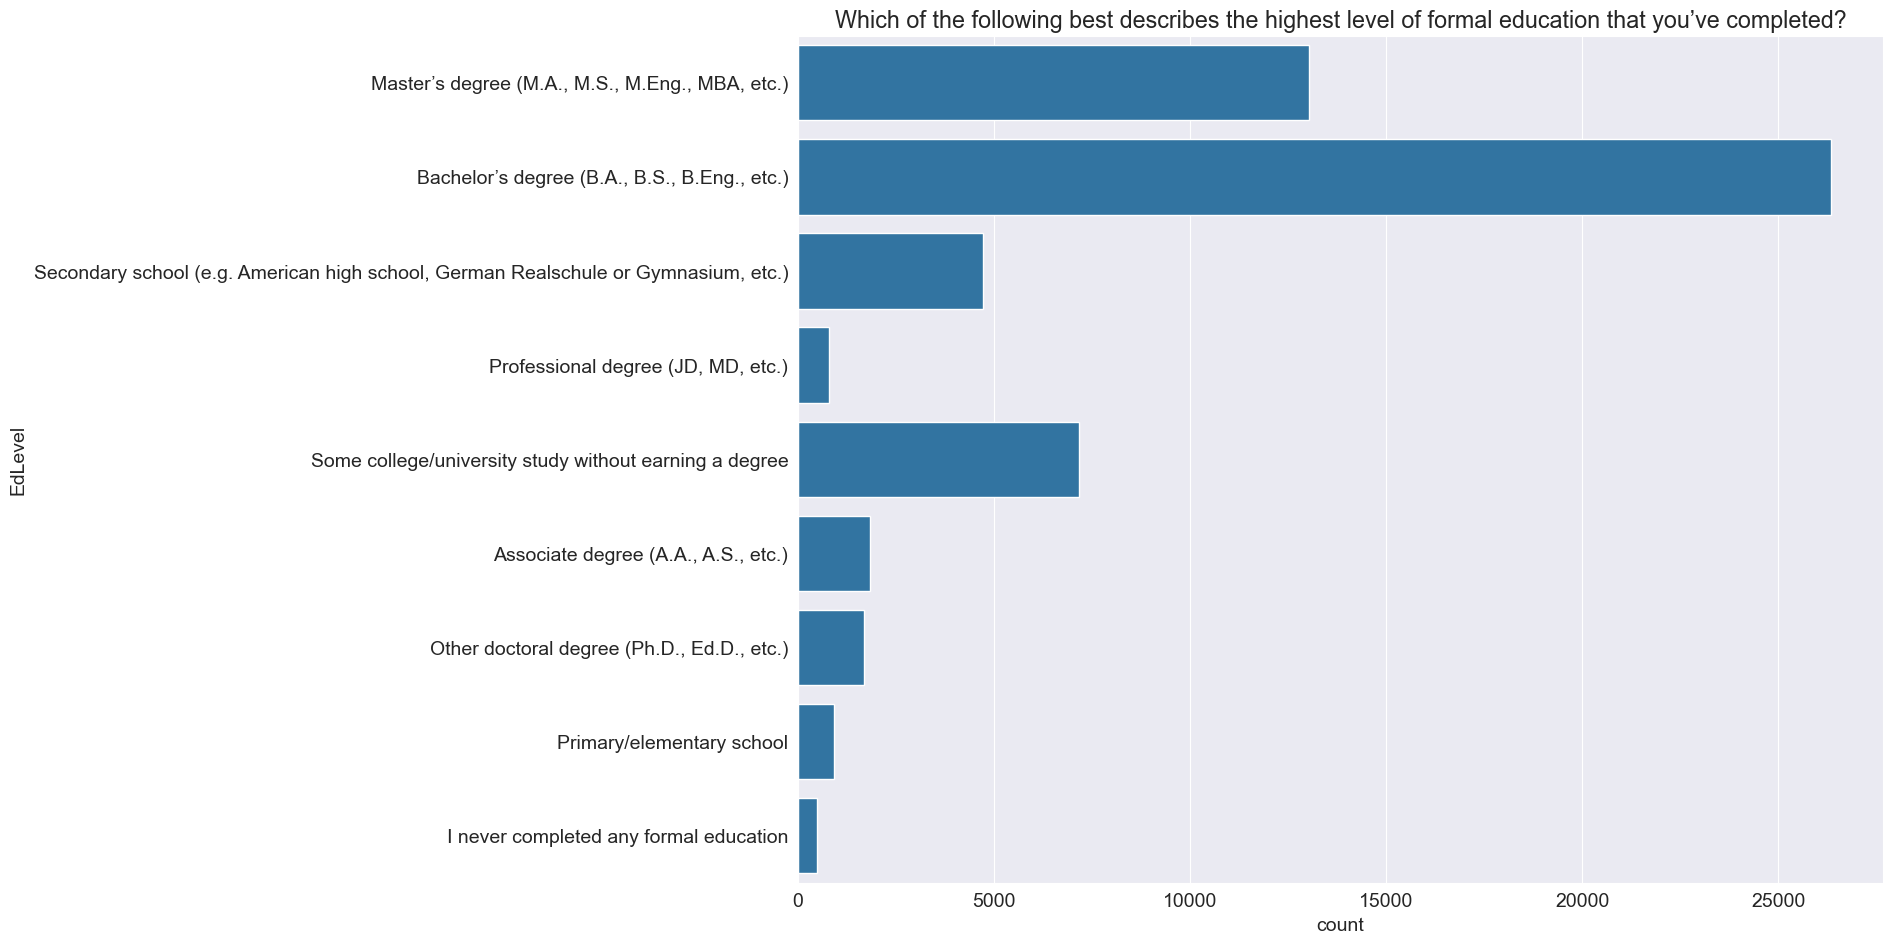

In [39]:
plt.figure(figsize = (14,11))
plt.title(schema.EdLevel)
sns.countplot(y = 'EdLevel' , data = survey)

# Undergraguate Major 

In [40]:
schema.UndergradMajor

'What was your primary field of study?'

In [41]:
# this time find insights in percentage
undergrad_pct = (survey.UndergradMajor.value_counts(normalize = True)*100).reset_index()
undergrad_pct.columns = ['undergrad' , 'proportion']
undergrad_pct

,undergrad,proportion
0,"Computer science, computer engineering, or sof...",61.939193
1,"Another engineering discipline (such as civil,...",9.354195
2,"Information systems, information technology, o...",7.983168
3,"A natural science (such as biology, chemistry,...",4.316561
4,Mathematics or statistics,3.627097
5,Web development or web design,3.502637
6,"A business discipline (such as accounting, fin...",2.700567
7,"A humanities discipline (such as literature, h...",1.969616
8,"A social science (such as anthropology, psycho...",1.821450
9,Fine arts or performing arts (such as graphic ...,1.412513


<Axes: title={'center': 'What was your primary field of study?'}, xlabel='proportion', ylabel='undergrad'>

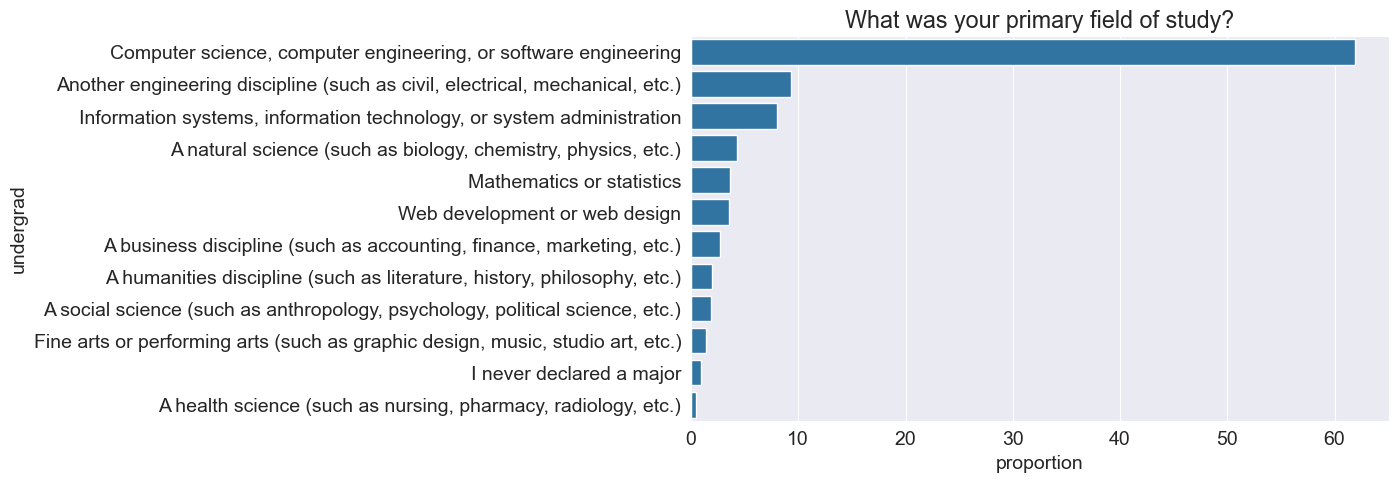

In [42]:
plt.title(schema.UndergradMajor)
sns.barplot(  y = 'undergrad',x = 'proportion' , data = undergrad_pct)

In [43]:
survey.sample(10)

,Age,Country,EdLevel,Gender,UndergradMajor,Age1stCode,LanguageDesireNextYear,LanguageWorkedWith,Hobbyist,YearsCode,YearsCodePro,NEWLearn,NEWStuck,Employment,NEWEdImpt,NEWOvertime,WorkWeekHrs,JobSat,DevType,JobFactors
5916,20.0,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",17.0,JavaScript;Python,C;C#;C++;Dart;HTML/CSS;Java;PHP;SQL,No,4.0,1.0,Once a year,Call a coworker or friend;Visit Stack Overflow,Employed full-time,Not at all important/not necessary,Often: 1-2 days per week or more,50.0,Very dissatisfied,"Designer;Developer, front-end;Developer, mobile",NaN
21150,23.0,Turkey,NaN,Man,"Computer science, computer engineering, or sof...",18.0,Dart;JavaScript;Kotlin;Python;Swift,C#;C++;Dart;HTML/CSS;Java;JavaScript;Kotlin;Py...,No,5.0,1.0,Once a year,Visit Stack Overflow;Watch help / tutorial videos,Employed full-time,Very important,Never,40.0,Slightly satisfied,"Developer, mobile","Flex time or a flexible schedule;Languages, fr..."
52628,35.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,Web development or web design,15.0,C#;HTML/CSS;JavaScript;PHP;Python;Ruby;SQL;Swi...,C#;HTML/CSS;JavaScript;PHP;SQL;Swift;VBA,Yes,20.0,16.0,Once every few years,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,Fairly important,Sometimes: 1-2 days per month but less than we...,40.0,Very satisfied,"Database administrator;Designer;Developer, bac...",Flex time or a flexible schedule;How widely us...
52767,49.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"A business discipline (such as accounting, fin...",13.0,C#;Go;Java;PHP;Python;R;SQL,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...,Yes,25.0,18.0,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,42.0,Slightly satisfied,"Database administrator;Developer, back-end;Dev...",Remote work options;Opportunities for professi...
31425,20.0,Germany,"Secondary school (e.g. American high school, G...",Man,NaN,14.0,Python,C;HTML/CSS;Java;SQL,No,5.0,NaN,Once a year,Visit Stack Overflow;Panic;Watch help / tutori...,Student,NaN,NaN,NaN,NaN,NaN,Flex time or a flexible schedule;Financial per...
29901,16.0,Poland,Primary/elementary school,Man,NaN,10.0,HTML/CSS;JavaScript,HTML/CSS;JavaScript;PHP,Yes,3.0,NaN,Every few months,Visit Stack Overflow;Watch help / tutorial vid...,Student,NaN,NaN,NaN,NaN,NaN,Flex time or a flexible schedule;Remote work o...
50907,30.0,United Kingdom,Some college/university study without earning ...,Man,Web development or web design,19.0,JavaScript;PHP;Python;SQL;TypeScript,HTML/CSS;JavaScript;PHP;Python;SQL,Yes,11.0,3.0,Every few months,Play games;Watch help / tutorial videos,Employed full-time,Somewhat important,Often: 1-2 days per week or more,42.0,Slightly satisfied,"Database administrator;Developer, back-end;Dev...","Languages, frameworks, and other technologies ..."
46740,25.0,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Another engineering discipline (such as civil,...",16.0,Go;HTML/CSS;TypeScript,HTML/CSS;JavaScript;Ruby;SQL;TypeScript,Yes,7.0,3.0,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...",Somewhat important,Rarely: 1-2 days per year or less,40.0,Slightly satisfied,"Designer;Developer, full-stack;Developer, mobile","Languages, frameworks, and other technologies ..."
7716,30.0,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",18.0,HTML/CSS;Java;JavaScript;TypeScript,HTML/CSS;JavaScript;TypeScript,Yes,10.0,7.0,Once a year,Visit Stack Overflow;Watch help / tutorial videos,Employed full-time,Very important,Often: 1-2 days per week or more,45.0,Neither satisfied nor dissatisfied,"Developer, front-end;Developer, full-stack",Flex time or a flexible schedule;Financial per...
39808,NaN,Afghanistan,NaN,NaN,NaN,

# Employment 

In [44]:
survey.Employment.value_counts()

Employment
Employed full-time                                      44958
Student                                                  7734
Independent contractor, freelancer, or self-employed     5619
Not employed, but looking for work                       2324
Employed part-time                                       2200
Not employed, and not looking for work                    318
Retired                                                   241
Name: count, dtype: int64

<Axes: title={'center': 'Which of the following best describes your current employment status?'}, ylabel='Employment'>

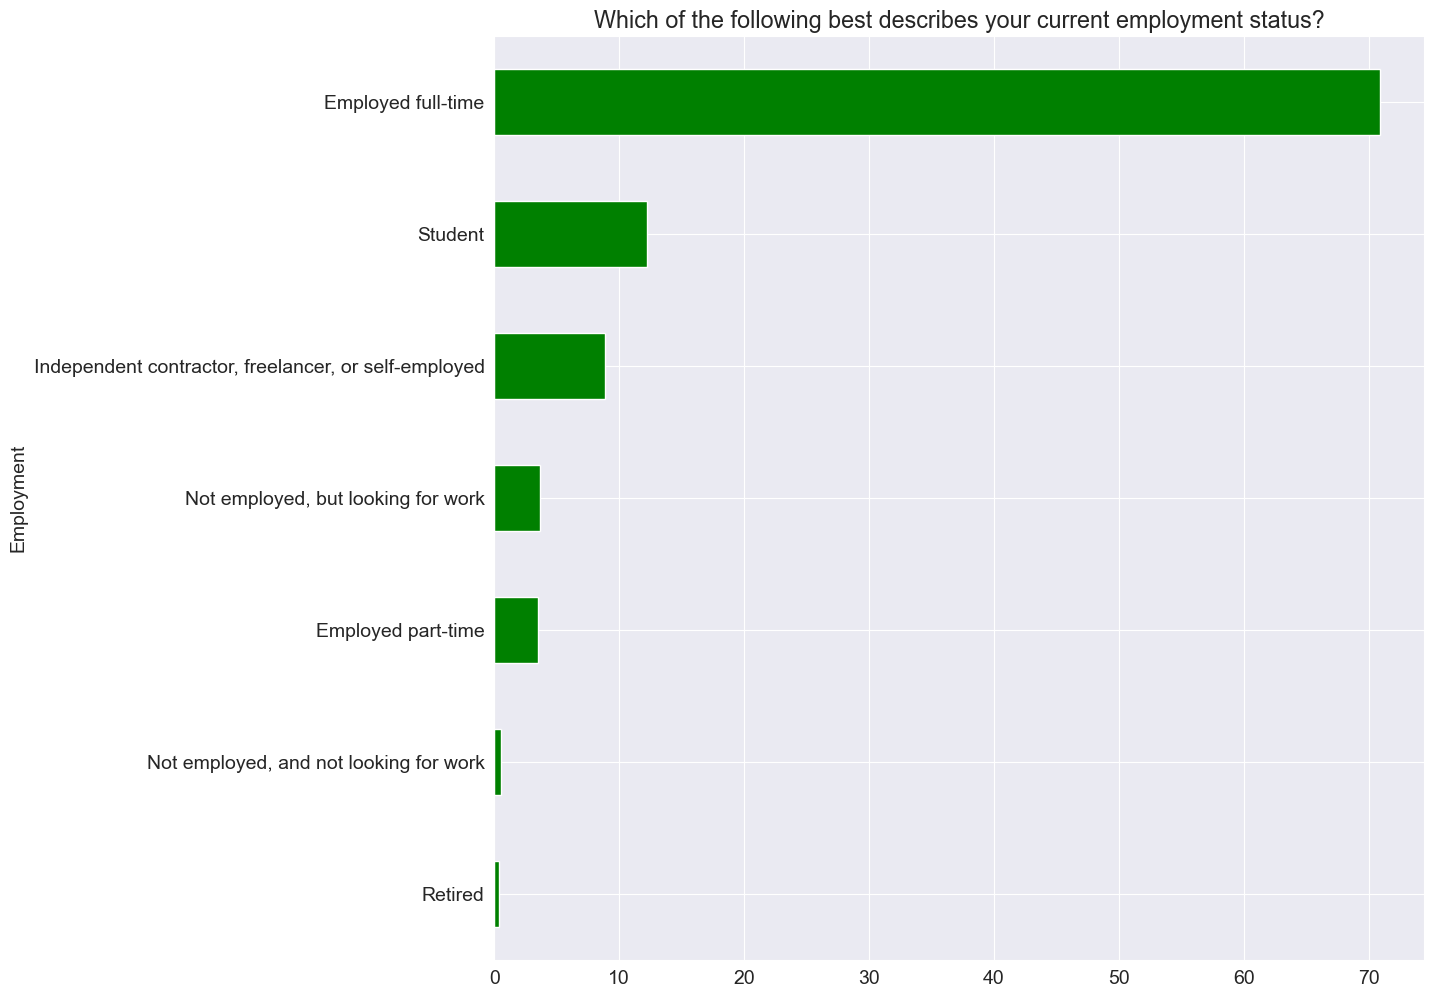

In [45]:
plt.figure(figsize=(12,12))
plt.title(schema.Employment)
(survey.Employment.value_counts(normalize = True,ascending = True)*100).plot(kind = 'barh',color = 'g')

# DevType

In [46]:
schema.DevType 

'Which of the following describe you? Please select all that apply.'

Each respondent can select multiple option. 

In [47]:
survey.DevType.value_counts()
survey.DevType.head()

0    Developer, desktop or enterprise applications;...
1              Developer, full-stack;Developer, mobile
2                                                  NaN
3                                                  NaN
4                                                  NaN
Name: DevType, dtype: object

From above we can not configure about the role as it was so diversed and it makes it confused so in such cases we shoud use *One Hot Encoding*

In [48]:
# In pandas, .items() lets you loop through each index-value pair in a Series (or column).
# It returns one pair at a time: the row index and the cell's value.

def split_multicolumn(col_series):
    result_df = col_series.to_frame()
    options=[]
    for idx , value in col_series[col_series.notnull()].items():
        for option in value.split(';'):
            if option not in result_df.columns:
                options.append(option)
                result_df[option] = False
            result_df.at[idx , option] = True
    return result_df[options]

In [49]:
multi_dev = split_multicolumn(survey['DevType'])
multi_dev

,"Developer, desktop or enterprise applications","Developer, full-stack","Developer, mobile",Designer,"Developer, front-end","Developer, back-end","Developer, QA or test",DevOps specialist,"Developer, game or graphics",Database administrator,...,System administrator,Engineering manager,Product manager,Data or business analyst,Academic researcher,Data scientist or machine learning specialist,Scientist,Senior executive/VP,"Engineer, site reliability",Marketing or sales professional
0,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
64457,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
multi_dev.sum().sort_values(ascending = False)

Developer, back-end                              26996
Developer, full-stack                            26915
Developer, front-end                             18128
Developer, desktop or enterprise applications    11687
Developer, mobile                                 9406
DevOps specialist                                 5915
Database administrator                            5658
Designer                                          5262
System administrator                              5185
Developer, embedded applications or devices       4701
Data or business analyst                          3970
Data scientist or machine learning specialist     3939
Developer, QA or test                             3893
Engineer, data                                    3700
Academic researcher                               3502
Educator                                          2895
Developer, game or graphics                       2751
Engineering manager                               2699
Product ma

**Question - which were the most popular programming language in 2020**

To Answer this question we will use *LanguageWorkedWith* column.

In [51]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63995 entries, 0 to 64460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     45068 non-null  float64
 1   Country                 63606 non-null  object 
 2   EdLevel                 56981 non-null  object 
 3   Gender                  50115 non-null  object 
 4   UndergradMajor          50619 non-null  object 
 5   Age1stCode              57027 non-null  float64
 6   LanguageDesireNextYear  53688 non-null  object 
 7   LanguageWorkedWith      56932 non-null  object 
 8   Hobbyist                63950 non-null  object 
 9   YearsCode               56339 non-null  float64
 10  YearsCodePro            43794 non-null  float64
 11  NEWLearn                55730 non-null  object 
 12  NEWStuck                54537 non-null  object 
 13  Employment              63394 non-null  object 
 14  NEWEdImpt               48092 non-null  obj

In [52]:
schema.LanguageWorkedWith      

'Which programming, scripting, and markup languages have you done extensive development work in over the past year, and which do you want to work in over the next year? (If you both worked with the language and want to continue to do so, please check both boxes in that row.)'

In [53]:
survey.LanguageWorkedWith.value_counts()  

LanguageWorkedWith
HTML/CSS;JavaScript;PHP;SQL                                                                           1065
HTML/CSS;JavaScript                                                                                    895
C#;HTML/CSS;JavaScript;SQL                                                                             849
C#;HTML/CSS;JavaScript;SQL;TypeScript                                                                  744
HTML/CSS;JavaScript;TypeScript                                                                         693
                                                                                                      ... 
Assembly;C;C#;C++;Dart;Go;Haskell;Java;JavaScript;Julia;Kotlin;Objective-C;PHP;Python;Ruby               1
Assembly;C;Go;Kotlin;Objective-C;Perl;PHP;Python;R                                                       1
Assembly;Scala                                                                                           1
Bash/Shell/PowerSh

In [54]:
lang_used = split_multicolumn(survey.LanguageWorkedWith)
lang_used 

,C#,HTML/CSS,JavaScript,Swift,Objective-C,Python,Ruby,SQL,Java,PHP,...,VBA,Perl,Scala,C++,Go,Haskell,Rust,Dart,Julia,Assembly
0,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [55]:
lang_used.sum().sort_values(ascending = False)

JavaScript               38515
HTML/CSS                 35884
SQL                      31153
Python                   25080
Java                     22905
Bash/Shell/PowerShell    18803
C#                       17879
PHP                      14874
TypeScript               14444
C++                      13578
C                        12370
Go                        4989
Kotlin                    4429
Ruby                      4006
Assembly                  3503
VBA                       3469
Swift                     3361
R                         3257
Rust                      2893
Objective-C               2317
Dart                      2262
Scala                     2026
Perl                      1773
Haskell                   1197
Julia                      503
dtype: int64

In [56]:
percentage = lang_used.mean().sort_values(ascending = False)*100
percentage = percentage.reset_index()

<Axes: title={'center': 'Most popular programming language in 2020'}, xlabel='perc', ylabel='lang'>

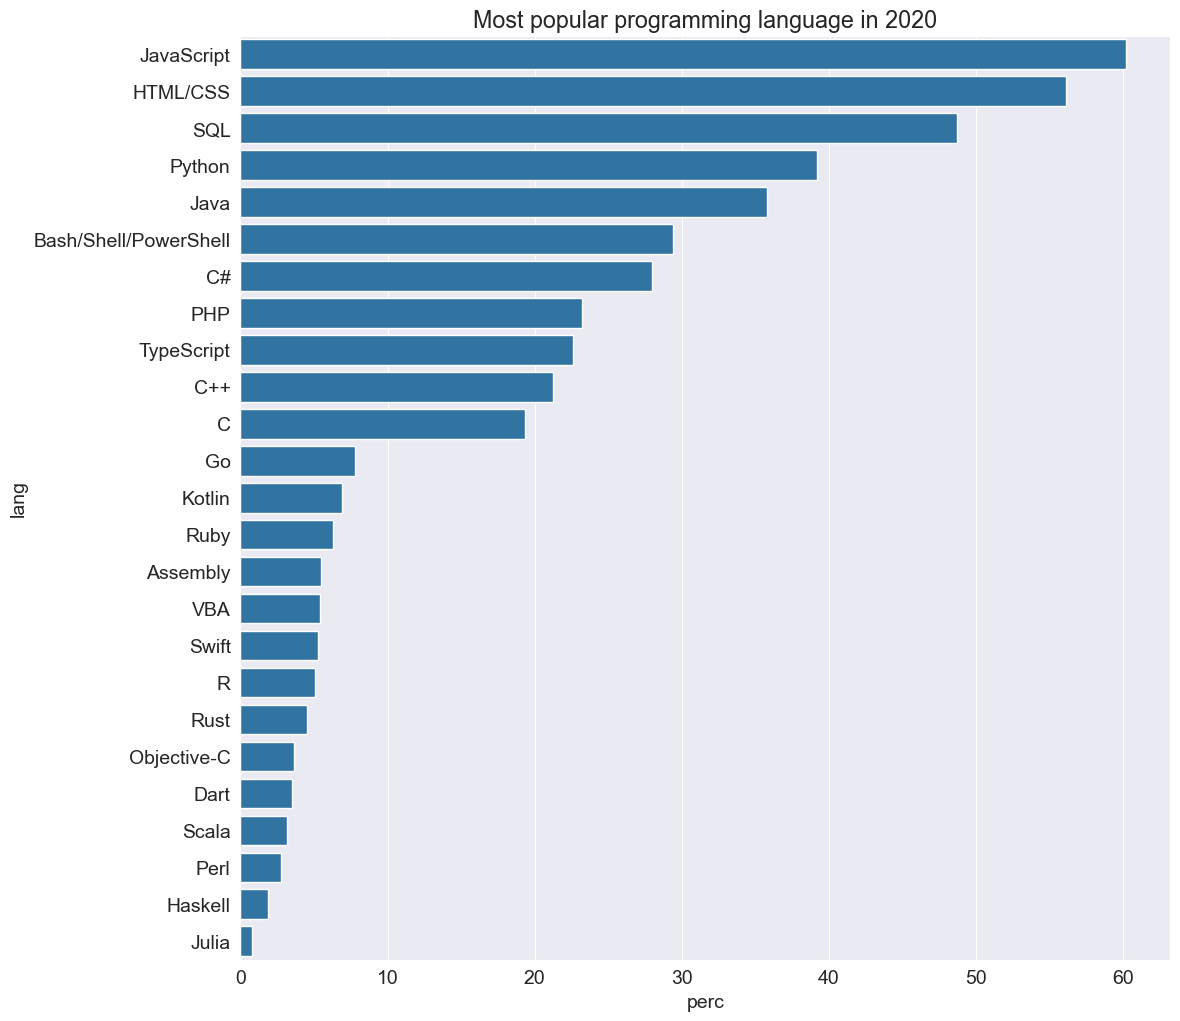

In [57]:
plt.figure(figsize = (12,12))
plt.title('Most popular programming language in 2020')
percentage.columns = ['lang' , 'perc']
sns.barplot( x = 'perc', y = 'lang',  data = percentage)

**Question - which were the most popular programming language used by developers older than 35 years of their age**

In [58]:
lang_35 = survey[survey['Age'] >= 35]

In [68]:
lang_35

,Age,Country,EdLevel,Gender,UndergradMajor,Age1stCode,LanguageDesireNextYear,LanguageWorkedWith,Hobbyist,YearsCode,YearsCodePro,NEWLearn,NEWStuck,Employment,NEWEdImpt,NEWOvertime,WorkWeekHrs,JobSat,DevType,JobFactors
7,36.0,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",12.0,JavaScript,Python;SQL,Yes,17.0,13.0,Once a year,Play games;Call a coworker or friend;Visit Sta...,Employed full-time,Not at all important/not necessary,Occasionally: 1-2 days per quarter but less th...,39.0,Slightly dissatisfied,"Developer, back-end;Developer, desktop or ente...",Remote work options;Opportunities for professi...
11,49.0,Spain,Some college/university study without earning ...,Man,Mathematics or statistics,42.0,HTML/CSS;JavaScript,HTML/CSS;JavaScript,No,7.0,7.0,Once every few years,Visit Stack Overflow,Employed full-time,Somewhat important,Rarely: 1-2 days per year or less,40.0,Very dissatisfied,"Designer;Developer, front-end",Remote work options;Office environment or comp...
12,53.0,Netherlands,"Secondary school (e.g. American high school, G...",Man,NaN,14.0,Python,C;JavaScript;Python,Yes,35.0,20.0,Once every few years,Call a coworker or friend;Go for a walk or oth...,Employed full-time,Not at all important/not necessary,Rarely: 1-2 days per year or less,36.0,Very satisfied,"Designer;Developer, back-end",Industry that I’d be working in;Financial perf...
15,45.0,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Computer science, computer engineering, or sof...",8.0,Go,Bash/Shell/PowerShell;HTML/CSS;Java;JavaScript...,Yes,37.0,23.0,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...",Fairly important,Often: 1-2 days per week or more,50.0,Very satisfied,"Database administrator;Developer, back-end;Dev...",Industry that I’d be working in;Diversity of t...
19,40.0,Spain,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Man,"Another engineering discipline (such as civil,...",18.0,Go,Java;JavaScript;SQL,Yes,22.0,17.0,Once every few years,Meditate;Call a coworker or friend;Go for a wa...,Employed full-time,Very important,Often: 1-2 days per week or more,50.0,Neither satisfied nor dissatisfied,"Developer, desktop or enterprise applications",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64388,56.0,United States,"Associate degree (A.A., A.S., etc.)",Man,"A health science (such as nursing, pharmacy, r...",50.0,NaN,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,Yes,2.0,NaN,Once a year,NaN,Retired,Very important,NaN,NaN,NaN,NaN,NaN
64392,36.0,Bangladesh,NaN,NaN,NaN,35.0,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,Yes,NaN,12.0,NaN,Meditate;Play games;Call a coworker or friend;...,Employed full-time,Critically important,NaN,NaN,NaN,Academic researcher;Data or business analyst;D...,NaN
64411,44.0,Belgium,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,"Another engineering discipline (such as civil,...",15.0,HTML/CSS;Java;Kotlin;Python;SQL,NaN,Yes,NaN,NaN,NaN,Visit another developer community (please name):,NaN,Fairly important,NaN,NaN,NaN,NaN,NaN
64430,38.0,Israel,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Man,NaN,35.0,Haskell;HTML/CSS;JavaScript;Python;Rust,HTML/CSS;JavaScript;Python,Yes,3.0,NaN,Every few months,Meditate;Play games;Call a coworker or friend;...,"Not employed, but looking for work",Fairly important,NaN,NaN,NaN,NaN,NaN


In [70]:
lang_35 = split_multicolumn(lang_35.LanguageWorkedWith)

In [72]:
percentage_35 = lang_35.mean().sort_values(ascending = False)*100
percentage_35

JavaScript               65.584416
HTML/CSS                 59.003801
SQL                      58.948369
Bash/Shell/PowerShell    40.259740
Python                   38.137472
C#                       34.827368
Java                     32.538803
TypeScript               23.424137
PHP                      22.727273
C++                      18.783655
C                        17.136522
Go                        8.853342
VBA                       8.512829
Ruby                      8.330694
Perl                      5.970858
Kotlin                    5.677859
Swift                     5.598670
R                         5.543237
Assembly                  5.028508
Objective-C               4.608806
Rust                      3.975293
Scala                     3.666455
Dart                      2.248971
Haskell                   1.362053
Julia                     0.807729
dtype: float64

<Axes: title={'center': 'Most common language used by developer older than 35 yeasr of age'}, xlabel='value', ylabel='idx'>

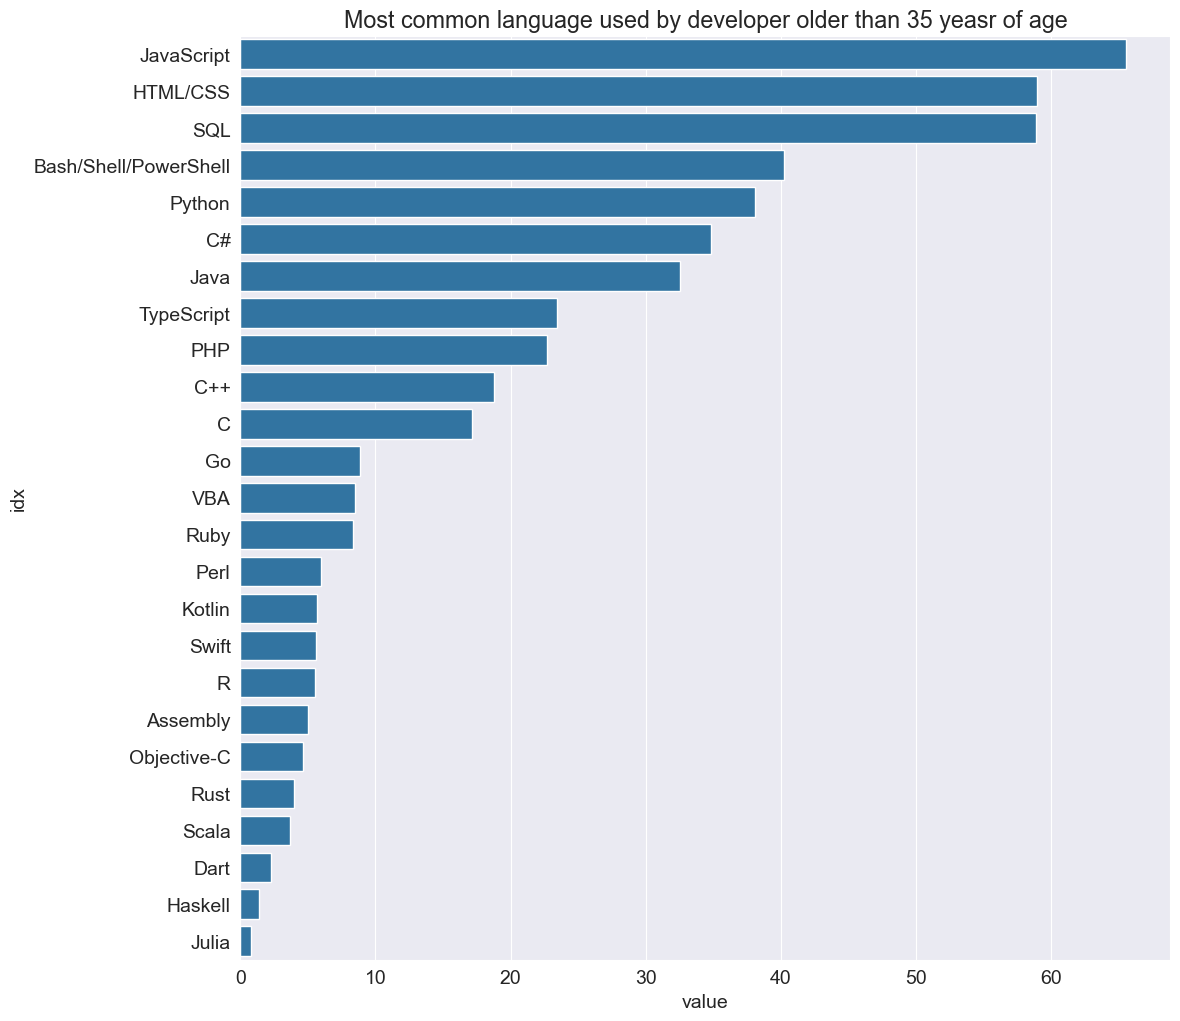

In [73]:
percentage_35 = percentage_35.reset_index()
percentage_35.columns = ['idx' , 'value']
plt.figure(figsize = (12,12))
plt.title('Most common language used by developer older than 35 yeasr of age')
sns.barplot( x = 'value' ,y = 'idx', data  = percentage_35)

From the above horizontal bar plot , it is cleared that Javascript holds the first position in the most common language race but if we carefully observed then we will see that java (the traditionally used language) is defeated by two other languages which are python and c# , one more thing is observed that shell/bash is widely used by the developers who is older than 35 years of their age , it means there should be a strong hold on commands if you are going into a corporate world 

**Question - which languages are the most people insterested to learn over the year**

In [74]:
survey.LanguageDesireNextYear.head()

0      C#;HTML/CSS;JavaScript
1                Python;Swift
2    Objective-C;Python;Swift
3                         NaN
4             Java;Ruby;Scala
Name: LanguageDesireNextYear, dtype: object

In [75]:
desire = split_multicolumn(survey.LanguageDesireNextYear)
desire

,C#,HTML/CSS,JavaScript,Python,Swift,Objective-C,Java,Ruby,Scala,PHP,...,Assembly,Bash/Shell/PowerShell,C,Haskell,Perl,C++,Julia,Kotlin,Dart,VBA
0,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,True,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
desire_perc = desire.mean().sort_values(ascending = False)*100 
desire_perc 

Python                   41.343855
JavaScript               40.621924
HTML/CSS                 32.183764
SQL                      30.949293
TypeScript               26.580202
C#                       21.161028
Java                     20.564107
Go                       19.526526
Bash/Shell/PowerShell    18.145168
Rust                     16.349715
C++                      15.087116
Kotlin                   14.832409
PHP                      11.000859
C                         9.405422
Swift                     8.735057
Dart                      7.344324
R                         6.603641
Ruby                      6.456754
Scala                     5.351981
Haskell                   4.615986
Assembly                  3.784671
Julia                     2.553324
Objective-C               2.350184
Perl                      1.770451
VBA                       1.618876
dtype: float64

In [77]:
desire_perc = desire_perc.reset_index()

<Axes: title={'center': 'Desired language to learn over the next year'}, xlabel='values', ylabel='idx'>

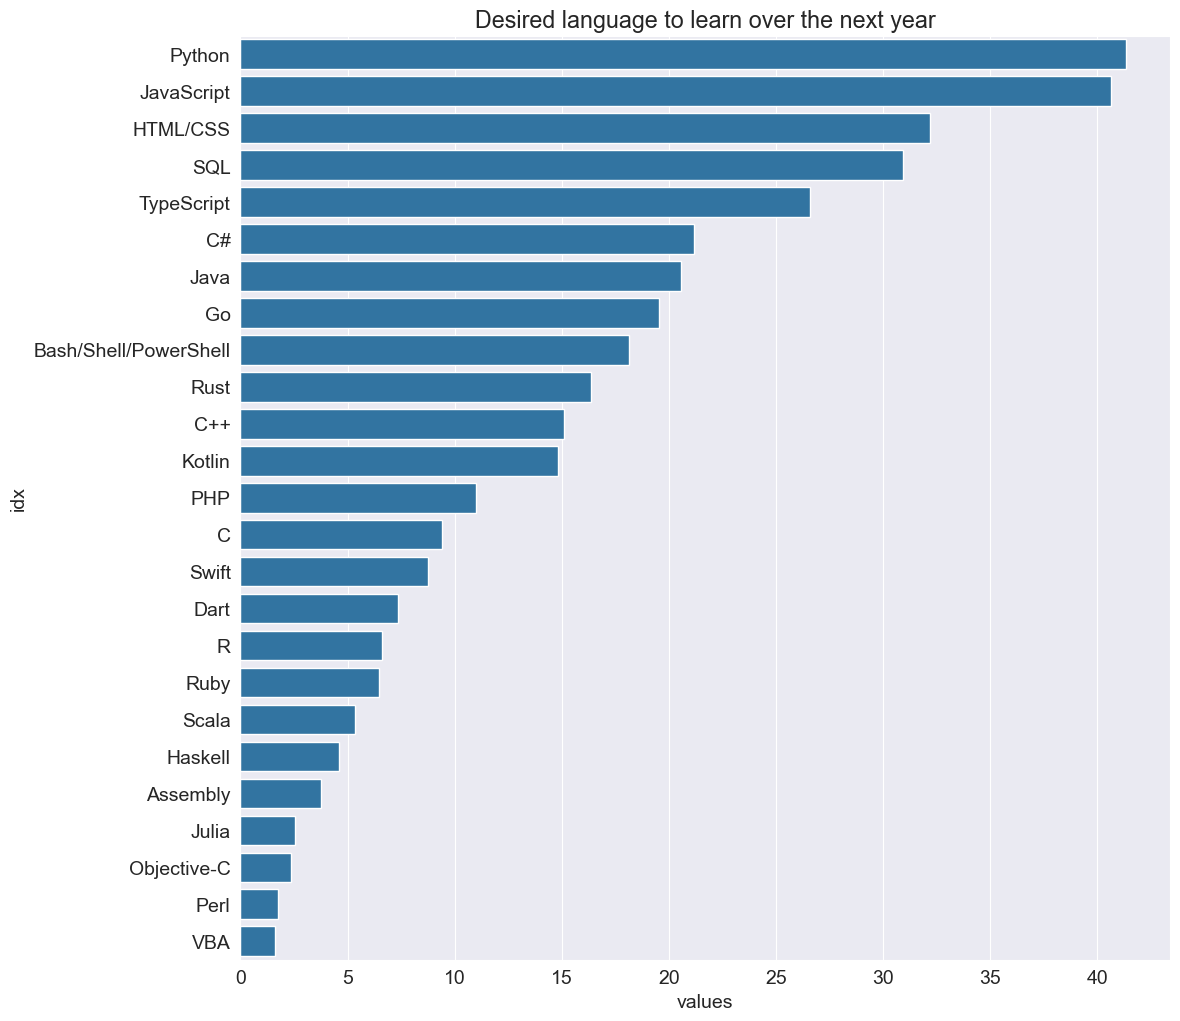

In [78]:
desire_perc.columns = ['idx' , 'values']
plt.figure(figsize = (12,12))
plt.title('Desired language to learn over the next year')
sns.barplot(x = 'values' , y = 'idx' , data = desire_perc )

<Axes: title={'center': 'Desirede language to be learn by the developers older than 35 yeasr of age'}, xlabel='value', ylabel='idx'>

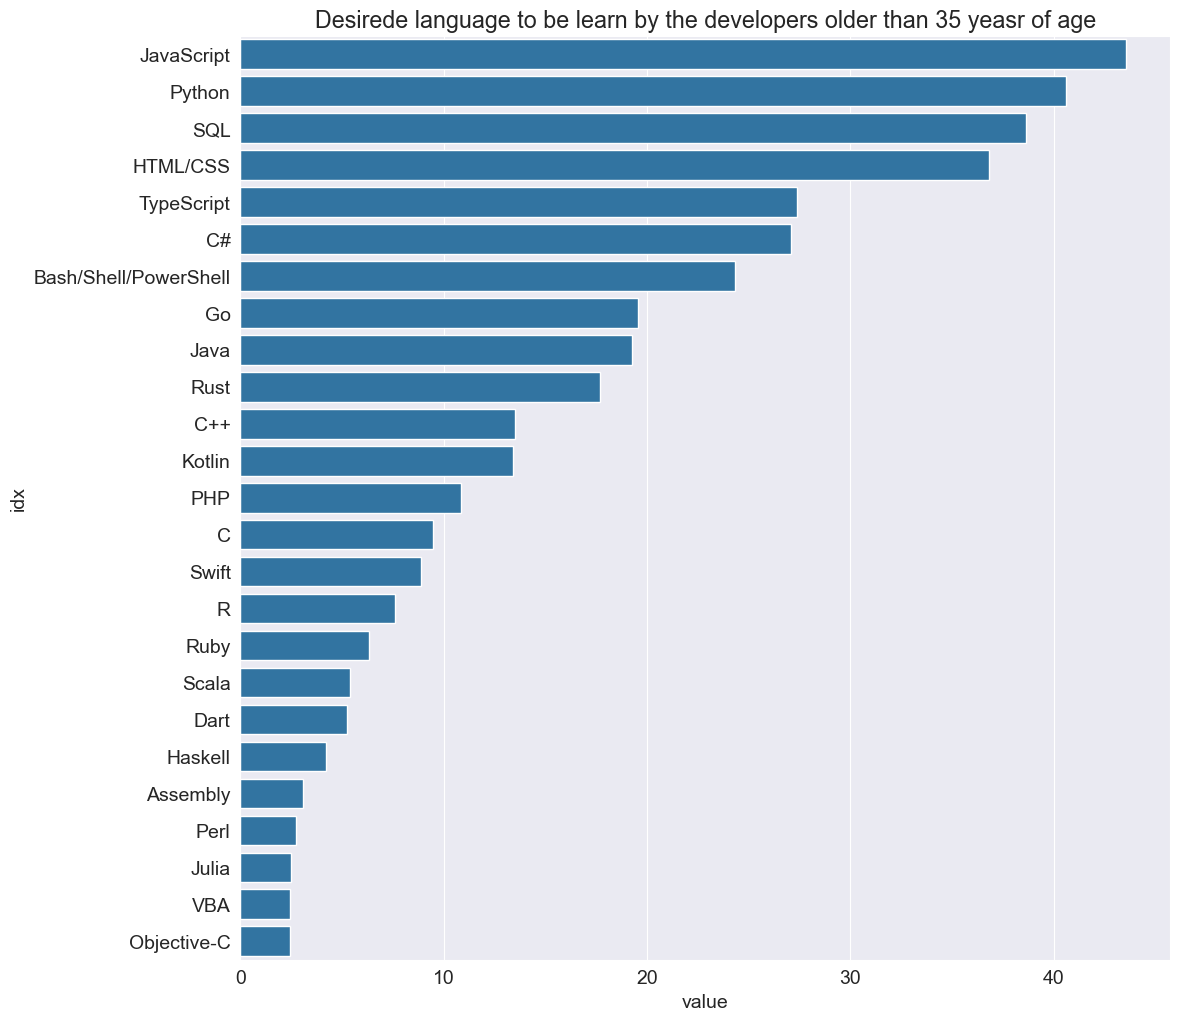

In [79]:
lang_35 = survey[survey['Age'] >= 35]
langused_35 = split_multicolumn(lang_35.LanguageDesireNextYear)
percentage_35 = langused_35.mean().sort_values(ascending = False)*100
percentage_35 = percentage_35.reset_index()
percentage_35.columns = ['idx' , 'value']
plt.figure(figsize = (12,12))
plt.title('Desirede language to be learn by the developers older than 35 yeasr of age')
sns.barplot( x = 'value' ,y = 'idx', data  = percentage_35)

**Q: In which countries do developers work the highest number of hours per week? Consider countries with more than 250 responses only.**

In [80]:
language_loved = lang_used & desire
language_loved 

,Assembly,Bash/Shell/PowerShell,C,C#,C++,Dart,Go,HTML/CSS,Haskell,Java,...,Perl,Python,R,Ruby,Rust,SQL,Scala,Swift,TypeScript,VBA
0,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [81]:
language_perc = (language_loved.sum()*100)/lang_used.sum()

In [82]:
language_perc = language_perc.sort_values(ascending = False).reset_index()
language_perc.columns = ['idx' ,'value']


<Axes: title={'center': 'Most Loved Language among the developers'}, xlabel='value', ylabel='idx'>

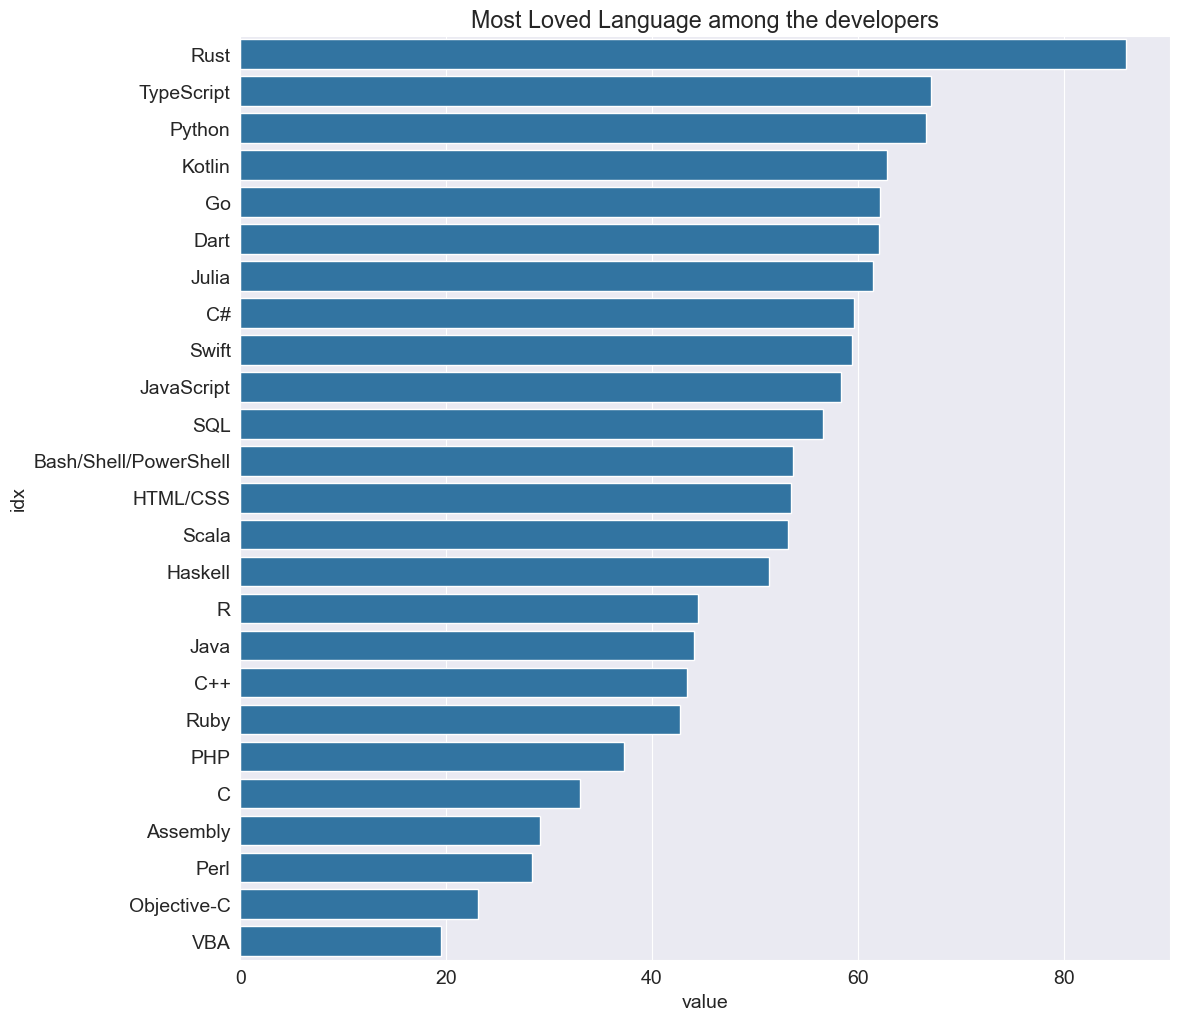

In [83]:
plt.figure(figsize = (12,12))
plt.title('Most Loved Language among the developers')
sns.barplot(x = 'value' , y = 'idx' , data = language_perc)

**Q: In which countries do developers work the highest number of hours per week? Consider countries with more than 250 responses only.**

In [93]:
# sample 
survey.groupby('Country')[['WorkWeekHrs','Age']].mean().sort_values('WorkWeekHrs',ascending = False)

,WorkWeekHrs,Age
Country,,
Kuwait,58.222222,29.111111
Iraq,52.153846,24.736842
Grenada,50.000000,NaN
Maldives,47.300000,18.666667
Afghanistan,46.500000,23.571429
...,...,...
North Korea,NaN,NaN
Saint Lucia,NaN,31.000000
Sierra Leone,NaN,27.000000


In [95]:
countries_df = survey.groupby('Country')['WorkWeekHrs'].mean().sort_values(ascending = False)

In [97]:
high_response_countries  = countries_df.loc[survey.Country.value_counts()>=250]

In [98]:
high_response_countries

Country
Iran                  44.337748
Israel                43.915094
China                 42.150000
United States         41.802982
Greece                41.402724
Viet Nam              41.391667
South Africa          41.023460
Turkey                40.982143
Sri Lanka             40.612245
New Zealand           40.457551
Belgium               40.444444
Canada                40.208837
Hungary               40.194340
Bangladesh            40.097458
India                 40.090603
Japan                 40.039409
Pakistan              39.950882
Australia             39.828234
Italy                 39.788462
Sweden                39.707006
Egypt                 39.653153
Ireland               39.596037
Switzerland           39.591071
Ukraine               39.543417
Serbia                39.520942
Bulgaria              39.509091
Mexico                39.352601
Spain                 39.304632
Czech Republic        39.288571
Russian Federation    39.250340
Norway                39.183636


In [100]:
survey.corr(numeric_only = True)

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
Age,1.000000,0.085059,0.801159,0.843045,0.088050
Age1stCode,0.085059,1.000000,-0.294512,-0.176750,-0.011336
YearsCode,0.801159,-0.294512,1.000000,0.882342,0.083950
YearsCodePro,0.843045,-0.176750,0.882342,1.000000,0.085258
WorkWeekHrs,0.088050,-0.011336,0.083950,0.085258,1.000000
